# Clique Cover Problem

Here we show how to solve the clique cover problem using OpenJij, [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html), and ommx-openjij-adapter. This problem is also mentioned in 6.2. Clique Cover in [Lucas, 2014, "Ising formulations of many NP problems"](https://doi.org/10.3389/fphy.2014.00005).

## Overview of the Clique Cover Problem

The clique covering problem is to determine whether, given a graph and an integer $n$, the graph can be partitioned into $n$ cliques (complete graphs).

### Complete Graph

A complete graph is a graph whose two vertices are all adjacent to each other (not including loops or multiple edges).
We show two examples below.

![](../../../assets/clique_cover_01.png)

As mentioned, a vertex in a complete graph is adjacent to all other vertices.
A complete undirected graph $G = (V, E)$ has ${}_V C_2 = \frac{1}{2} V(V-1)$ edges, which shows that the number of edges is equal to the number of combinations choosing two vertices from $V$.
Based on minimizing the difference in the number of edges from a complete graph, we describe a mathematical model for the clique cover problem.

### Binary Variable

We introduce a binary variable $x_{v, n}$ such that $x_{v, n}$ is 1 if the vertex $v$ belongs to the $n$th clique and 0 otherwise.

### Constraint: Each vertex can belong to only one clique

The graph is divided into $N$ cliques:

$$
\sum_{n=0}^{N-1} x_{v, n} = 1 \quad (\forall v \in V) \tag{1}
$$

### Objective Function: Minimize the difference from a complete graph

Let us consider the $n$th subgraph. The number of vertices is $V_n (=\sum_v x_{v, n})$. If this subgraph is complete, the number of edges is $\frac{1}{2} V_n (V_n -1)$. The number of edges that the vertices actually form can be written as $\sum_{(uv) \in E} x_{u, n} x_{v, n}$ using the edge set $E$. The closer the difference between these two is to zero, the more neatly the graph is divided into cliques. Therefore, the objective function is:

$$
\mathrm{obj} = \sum_{n=0}^{N-1} \left\{ \frac{1}{2} \left( \sum_{v=0}^{V-1} x_{v, n}\right) \left( \sum_{v=0}^{V-1} x_{v, n}-1\right) - \sum_{(uv) \in E}x_{u, n} x_{v, n}\right\} \tag{2}
$$

## Formulation with JijModeling

Next, we show how to formulate the above mathematical model using JijModeling. We first define the variables and parameters used in the model.

In [1]:
import jijmodeling as jm

problem = jm.Problem('Clique Cover')

V = problem.Natural('V')
E = problem.Graph('E')
N = problem.Natural('N')
x = problem.BinaryVar('x', shape=(V, N))

### Constraint

Let us formulate the constraint in equation (1).

In [2]:
problem += problem.Constraint('color', lambda v: jm.sum(N, lambda n: x[v, n]) == 1, domain=V)

### Objective Function

Let us formulate the objective function in equation (2).

In [3]:
problem += jm.sum(
    N, 
    lambda n: 0.5 * jm.sum(V, lambda v: x[v, n]) * (jm.sum(V, lambda v: x[v, n])-1) - jm.sum(E, lambda e: x[e[0], n]*x[e[1], n]),
)

Let us display the formulated mathematical model in the Jupyter Notebook.

In [4]:
problem

Problem(name="Clique Cover", sense=MINIMIZE, objective=sum(N.map(lambda (n: natural): 0.5 * sum(V.map(lambda (v: natural): x[v, n])) * (sum(V.map(lambda (v: natural): x[v, n])) - 1) - sum(E.map(lambda (e: Tuple[natural, natural]): x[e[0], n] * x[e[1], n])))), constraints={color: [Constraint(name="color", , lambda v: sum(N.map(lambda (n: natural): x[v, n])) == 1, domain=set(V)),],})

## Creating an Instance

Let us set up the graph for clique cover.

In [5]:
import networkx as nx

# set the number of colors
inst_N = 3
# set empty graph
inst_G = nx.Graph()
# add edges
inst_E = [[0, 1], [1, 2], [0, 2], 
            [3, 4], [4, 5], [5, 6], [3, 6], [3, 5], [4, 6], 
            [7, 8], [8, 9], [7, 9], 
            [1, 3], [2, 6], [5, 7], [5, 9]]
inst_G.add_edges_from(inst_E)
# get the number of nodes
inst_V = list(inst_G.nodes)
num_V = len(inst_V)
instance_data = {'N': inst_N, 'V': num_V, 'E': inst_E}

The graph set up by this instance is as follows.

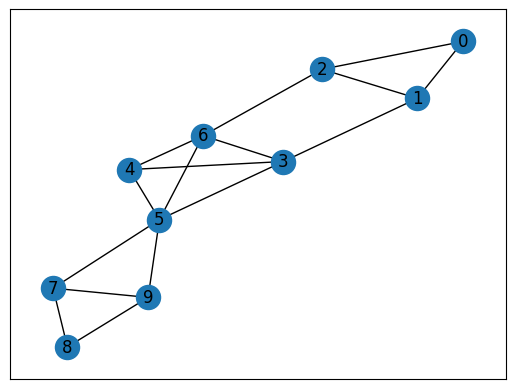

In [6]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(inst_G)
nx.draw_networkx(inst_G, pos=pos, with_labels=True)
plt.show()

This graph consists of three cliques {0, 1, 2}, {3, 4, 5, 6}, and {7, 8, 9}. Let us verify that it can actually be divided into cliques.

## Running Optimization with OpenJij

Let us solve the optimization problem using OpenJij's simulated annealing.

In [7]:
from ommx_openjij_adapter import OMMXOpenJijSAAdapter

instance = problem.eval(instance_data)

adapter = OMMXOpenJijSAAdapter(instance)
best_sample = adapter.sample(
    instance, num_reads=100, uniform_penalty_weight=1.1
).best_feasible_unrelaxed

## Visualizing the Solution

Let us visualize the obtained solution.

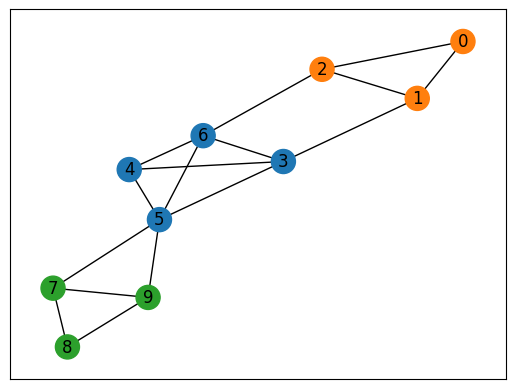

In [8]:
df = best_sample.decision_variables_df
x_indices = df[df["value"]==1.0]["subscripts"]
# initialize vertex color list
node_colors = [-1] * len(x_indices)
# set color list for visualization
cmap = plt.get_cmap("tab10")
colorlist = [cmap(i) for i in range(inst_N)]
# set vertex color list
for i, j in x_indices:
    node_colors[i] = colorlist[j]
# make figure
nx.draw_networkx(inst_G, pos=pos, node_color=node_colors, with_labels=True)
plt.show()

As expected, we can see that the graph is divided into three cliques.